# Modeling

This notebook trains and evaluates models that predict whether the server wins a point using only pre-serve information. The objective is to produce a calibrated probability estimate for each possible serve choice under a given match context, which the recommendation system in the next notebook will use to rank serve options.

Accuracy alone is an insufficient criterion for model selection: because the output is a probability score rather than a binary class label, the model must also be well-calibrated — a predicted win probability of 0.65 should correspond to an empirical win rate close to 65%.

Interpretability is a second priority alongside predictive performance. A serve recommendation system that cannot explain why a particular serve is favored is difficult for coaches and players to trust. For this reason we train a tuned LASSO logistic regression alongside more powerful ensemble methods. The LASSO model sacrifices some predictive accuracy in exchange for a sparse, readable coefficient vector that identifies which serve and context variables are most strongly associated with point outcomes.

## Imports and Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss, average_precision_score,
    ConfusionMatrixDisplay, classification_report
)

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

df = pd.read_csv('../data/processed/table_tennis_serves_features.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 500 rows × 52 columns


,serve_type,spin_type,spin_intensity,serve_length,placement_zone,toss_height,contact_point,match_id,game_number,server_score,...,serve_spin_combo,serve_length_spin_combo,serve_placement_combo,full_serve_combo,is_heavy_spin,is_low_spin,spin_length_interaction,combo_attempts,combo_win_rate,combo_reliability
0,backhand,float/no-spin,1,long,middle_FH,medium,body_center,1,1,0,...,backhand_float/no-spin,long_float/no-spin,backhand_middle_FH,backhand_float/no-spin_long_middle_FH,0,1,1_long,2,0.0,0.066667
1,backhand,float/no-spin,1,long,elbow,medium,body_center,1,1,0,...,backhand_float/no-spin,long_float/no-spin,backhand_elbow,backhand_float/no-spin_long_elbow,0,1,1_long,4,0.0,0.133333
2,backhand,float/no-spin,2,long,elbow,low,hip_level_backhand,1,1,0,...,backhand_float/no-spin,long_float/no-spin,backhand_elbow,backhand_float/no-spin_long_elbow,0,0,2_long,4,0.0,0.133333


## Feature Definition

We define the 33 features that will be passed to all models. Every feature satisfies the **pre-serve constraint**: its value is known before the serve is executed. Post-serve variables (`return_type`, `return_quality`, `rally_length`, `point_end_type`, `rally_type_achieved`, `chop_rally_outcome`) are intentionally excluded to prevent data leakage. Including them would produce artificially high evaluation scores during training but cause the model to fail entirely in deployment, where those values are undefined at the moment of the serve decision.

In [2]:
model_features = [
    # Serve mechanics
    'serve_type', 'spin_type', 'spin_intensity', 'serve_length', 'placement_zone',
    'toss_height', 'contact_point',
    # Game context
    'game_number', 'server_score', 'receiver_score', 'game_state',
    # Opponent characteristics
    'opponent_skill_level', 'opponent_style', 'side', 'intended_setup',
    # Engineered game-state flags
    'score_margin', 'total_points_played_in_game',
    'is_tied', 'is_trailing', 'is_leading',
    'is_late_game', 'is_deuce_or_later',
    'is_game_point_for_server', 'is_game_point_against_server',
    # Serve combination identifiers
    'serve_spin_combo', 'serve_length_spin_combo',
    'serve_placement_combo', 'full_serve_combo',
    # Spin flags
    'is_heavy_spin', 'is_low_spin',
    # Historical combination statistics
    'combo_attempts', 'combo_win_rate', 'combo_reliability'
]

X      = df[model_features]
y      = df['point_won']
groups = df['match_id']

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Matches : {groups.nunique()}  (used as GroupKFold groups)')

X shape : (500, 33)
y shape : (500,)
Matches : 8  (used as GroupKFold groups)


## Baseline Accuracy

Before training any model we establish a majority-class baseline: the accuracy a trivial classifier achieves by always predicting the most common class. This is the correct reference point for model evaluation. Comparing to 50% accuracy would be misleading when the class distribution is imbalanced; comparing to the majority-class rate is honest.

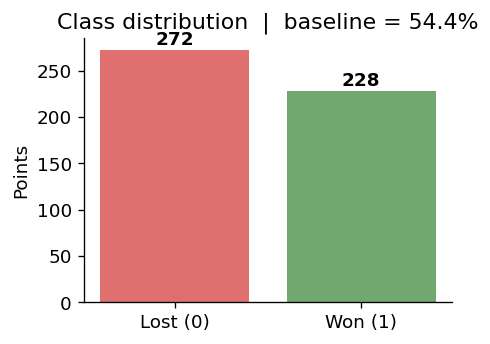

Won  : 228  (45.6%)
Lost : 272  (54.4%)
Baseline accuracy (always predict majority class): 0.544


In [3]:
baseline_accuracy = y.value_counts(normalize=True).max()

vc = y.value_counts()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Lost (0)', 'Won (1)'], [vc[0], vc[1]], color=['#e07070', '#70a870'])
ax.set_ylabel('Points')
ax.set_title(f'Class distribution  |  baseline = {baseline_accuracy:.1%}')
for bar, val in zip(ax.patches, [vc[0], vc[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Won  : {vc[1]}  ({vc[1]/len(y):.1%})')
print(f'Lost : {vc[0]}  ({vc[0]/len(y):.1%})')
print(f'Baseline accuracy (always predict majority class): {baseline_accuracy:.3f}')

## Preprocessing Pipeline

The feature set contains two distinct data types that require different preprocessing. Categorical string features such as `serve_type`, `spin_type`, and `full_serve_combo` are one-hot encoded with `handle_unknown='ignore'` so that novel combinations encountered at inference time are mapped to an all-zero vector rather than causing an error. Numeric features such as `spin_intensity`, `score_margin`, and `combo_win_rate` are standardised with `StandardScaler` so that they have zero mean and unit variance. Standardisation is essential for LASSO because L1 regularisation penalises the absolute magnitude of coefficients: without scaling, features measured on large scales would be penalised more heavily than those on small scales regardless of their actual importance. The `ColumnTransformer` applies each step only to the appropriate subset of columns.

In [4]:
# pandas ≥2.0 uses StringDtype; select_dtypes(include=['object']) catches both
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features     = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'Numeric features     ({len(numeric_features)}): {numeric_features}')

Categorical features (15): ['serve_type', 'spin_type', 'serve_length', 'placement_zone', 'toss_height', 'contact_point', 'game_state', 'opponent_skill_level', 'opponent_style', 'side', 'intended_setup', 'serve_spin_combo', 'serve_length_spin_combo', 'serve_placement_combo', 'full_serve_combo']
Numeric features     (18): ['spin_intensity', 'game_number', 'server_score', 'receiver_score', 'score_margin', 'total_points_played_in_game', 'is_tied', 'is_trailing', 'is_leading', 'is_late_game', 'is_deuce_or_later', 'is_game_point_for_server', 'is_game_point_against_server', 'is_heavy_spin', 'is_low_spin', 'combo_attempts', 'combo_win_rate', 'combo_reliability']


## Cross-Validation Strategy

Model evaluation uses `GroupKFold` with five folds, where each fold is defined so that all points from a given match appear exclusively in either the training set or the validation set. This match-level grouping is essential for producing an honest estimate of generalisation performance. If points from the same match were split across training and validation, the model could learn match-specific patterns — a particular opponent's tendencies in a specific game — that are not present in genuinely new matches. Using `GroupKFold` simulates the realistic deployment scenario where the model is evaluated on matches it has never seen. A model that achieves high accuracy only because it memorised match-specific patterns would receive an inflated score under standard k-fold CV but would be correctly penalised under this group-aware scheme.

In [5]:
cv = GroupKFold(n_splits=5)
print('GroupKFold with n_splits=5 and groups=match_id')
print('Each fold holds out one or two entire matches.')

GroupKFold with n_splits=5 and groups=match_id
Each fold holds out one or two entire matches.


## LASSO Logistic Regression

The first model is logistic regression with L1 regularisation. L1 regularisation adds a penalty equal to the sum of the absolute values of the model coefficients to the loss function, driving many coefficients exactly to zero. This produces a sparse model in which only a subset of features receive nonzero weights, making the model directly interpretable: each nonzero coefficient tells us whether the associated feature increases or decreases the log-odds of winning the point, and by how much.

Rather than using the default regularisation strength `C=1.0`, we sweep over a range of `C` values using `GridSearchCV` with group-aware cross-validation so that the sparsity level is tuned rather than arbitrary. We use `class_weight='balanced'` to prevent the model from optimising solely by predicting the majority class. We report both cross-validated accuracy and ROC-AUC, with ROC-AUC being the more informative metric because it measures the model's ability to rank positive cases above negative cases regardless of the classification threshold.

In [6]:
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        l1_ratio=1, solver='liblinear', max_iter=1000, class_weight='balanced'
    ))
])

param_grid = {'classifier__C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}
lasso_search = GridSearchCV(
    lasso_pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1
)
lasso_search.fit(X, y, groups=groups)

print(f'Best C     : {lasso_search.best_params_["classifier__C"]}')
print(f'Best CV AUC: {lasso_search.best_score_:.3f}')

lasso_model = lasso_search.best_estimator_

lasso_accuracy = cross_val_score(lasso_model, X, y, cv=cv, groups=groups, scoring='accuracy')
lasso_auc      = cross_val_score(lasso_model, X, y, cv=cv, groups=groups, scoring='roc_auc')
print(f'LASSO Accuracy : {lasso_accuracy.mean():.3f} ± {lasso_accuracy.std():.3f}')
print(f'LASSO ROC-AUC  : {lasso_auc.mean():.3f} ± {lasso_auc.std():.3f}')

Best C     : 0.01
Best CV AUC: 0.746
LASSO Accuracy : 0.671 ± 0.063
LASSO ROC-AUC  : 0.746 ± 0.062


In [7]:
lasso_fold_results = pd.DataFrame({
    'fold'    : list(range(1, 6)),
    'accuracy': lasso_accuracy,
    'roc_auc' : lasso_auc
})
print('LASSO per-fold scores:')
lasso_fold_results

LASSO per-fold scores:


,fold,accuracy,roc_auc
0,1,0.640449,0.773509
1,2,0.690141,0.695455
2,3,0.602041,0.679245
3,4,0.783333,0.852409
4,5,0.639344,0.729444


## LASSO Coefficient Plot

We fit the tuned LASSO model on the full dataset to extract the coefficient vector and identify which features survived regularisation with nonzero weights. The coefficient plot shows the top 15 features by absolute coefficient magnitude. A positive coefficient (green) means that higher values of that feature are associated with a higher predicted probability of winning the point. A negative coefficient (red) means the opposite. Features with a zero coefficient were eliminated by the L1 penalty and are not shown — this is itself informative: it tells us which features the regularisation procedure deemed redundant or uninformative given the presence of other features.

In [8]:
lasso_model.fit(X, y)
feature_names = lasso_model.named_steps['preprocessor'].get_feature_names_out()
coefficients  = lasso_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
important_features = (
    coef_df[coef_df['coefficient'] != 0]
    .sort_values('abs_coefficient', ascending=False)
)
print(f'Non-zero coefficients: {len(important_features)} / {len(coef_df)}')
important_features.head(20)

Non-zero coefficients: 270 / 270


,feature,coefficient,abs_coefficient
268,num__combo_win_rate,0.588377,0.588377
34,cat__opponent_skill_level_competitive,-0.171400,0.171400
33,cat__opponent_skill_level_beginner,0.117975,0.117975
256,num__score_margin,0.109464,0.109464
254,num__server_score,0.081760,0.081760
35,cat__opponent_skill_level_intermediate,0.071702,0.071702
39,cat__opponent_style_looper,-0.067856,0.067856
259,num__is_trailing,-0.062975,0.062975
42,cat__intended_setup_direct_point,-0.060057,0.060057
252,num__spin_intensity,0.055355,0.055355


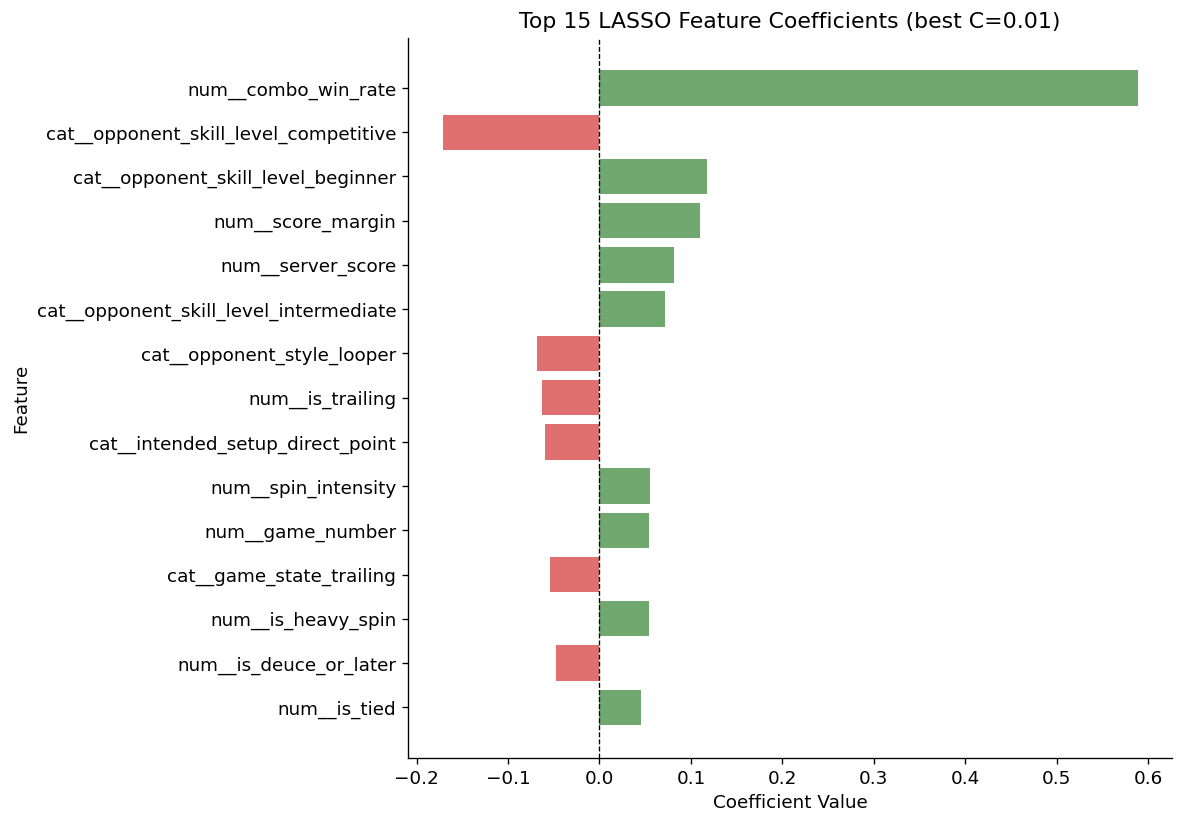

Green = positive (associated with winning); Red = negative (associated with losing).
Magnitude reflects strength of association after L1 regularisation.


In [9]:
top15_lasso = important_features.head(15).sort_values('abs_coefficient', ascending=True)
colors = ['#70a870' if c > 0 else '#e07070' for c in top15_lasso['coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_lasso['feature'], top15_lasso['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Top 15 LASSO Feature Coefficients (best C={lasso_search.best_params_["classifier__C"]})')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Green = positive (associated with winning); Red = negative (associated with losing).')
print('Magnitude reflects strength of association after L1 regularisation.')

## Random Forest

The second model is a Random Forest classifier. Random forests capture nonlinear relationships and feature interactions without requiring explicit interaction terms, which is an advantage when the true relationship between serve attributes and point outcomes is complex. We use 300 trees, which is sufficient for ensemble variance to converge. We tune `max_depth` and `min_samples_leaf` via a small grid search with group-aware cross-validation rather than fixing them at arbitrary defaults. `class_weight='balanced'` ensures the ensemble is not biased toward the majority class.

In [10]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced'
    ))
])

rf_param_grid = {
    'classifier__max_depth'       : [3, 5, 7],
    'classifier__min_samples_leaf': [5, 10, 20]
}
rf_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_search.fit(X, y, groups=groups)

print(f'Best RF params : {rf_search.best_params_}')
print(f'Best CV AUC    : {rf_search.best_score_:.3f}')

rf_model = rf_search.best_estimator_

rf_accuracy = cross_val_score(rf_model, X, y, cv=cv, groups=groups, scoring='accuracy')
rf_auc      = cross_val_score(rf_model, X, y, cv=cv, groups=groups, scoring='roc_auc')
print(f'Random Forest Accuracy : {rf_accuracy.mean():.3f} ± {rf_accuracy.std():.3f}')
print(f'Random Forest ROC-AUC  : {rf_auc.mean():.3f} ± {rf_auc.std():.3f}')

Best RF params : {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 20}
Best CV AUC    : 0.696
Random Forest Accuracy : 0.644 ± 0.023
Random Forest ROC-AUC  : 0.696 ± 0.083


In [11]:
rf_fold_results = pd.DataFrame({
    'fold'    : list(range(1, 6)),
    'accuracy': rf_accuracy,
    'roc_auc' : rf_auc
})
print('Random Forest per-fold scores:')
rf_fold_results

Random Forest per-fold scores:


,fold,accuracy,roc_auc
0,1,0.629213,0.724975
1,2,0.661972,0.672727
2,3,0.612245,0.585325
3,4,0.675000,0.835979
4,5,0.639344,0.659444


## Random Forest Feature Importance

Random forests provide two views of feature importance.

**Impurity-based importance** measures the average reduction in Gini impurity attributable to splits on each feature across all trees. An important caveat is that impurity-based importance can overestimate the importance of high-cardinality categorical features, because features with many distinct values have more opportunities to produce good splits by chance.

**Permutation importance** measures the drop in ROC-AUC when a single feature's values are randomly shuffled. It is not biased by cardinality and directly measures the contribution of each feature to out-of-sample predictive performance. We present both views as complementary diagnostics.

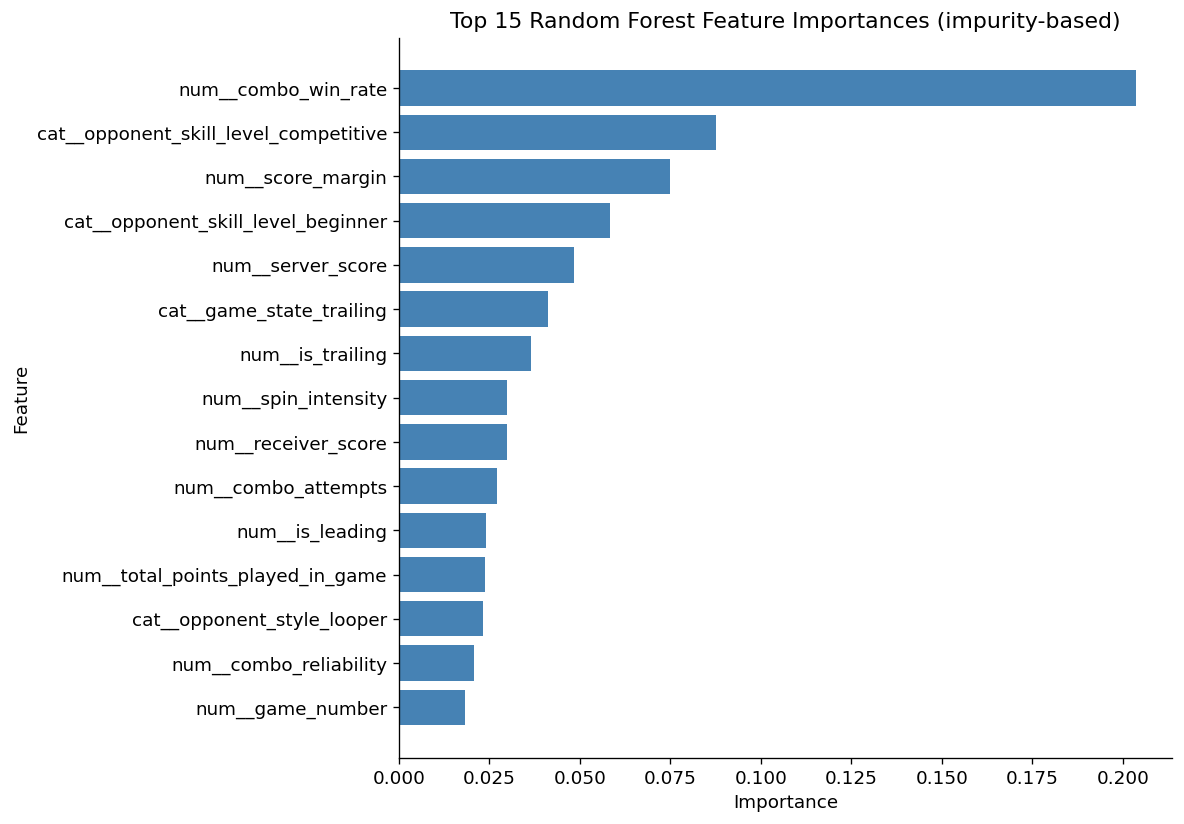

Top 20 impurity-based importances:


,feature,importance
268,num__combo_win_rate,0.203470
34,cat__opponent_skill_level_competitive,0.087478
256,num__score_margin,0.074859
33,cat__opponent_skill_level_beginner,0.058428
254,num__server_score,0.048255
31,cat__game_state_trailing,0.041196
259,num__is_trailing,0.036473
252,num__spin_intensity,0.029834
255,num__receiver_score,0.029746
267,num__combo_attempts,0.027068


In [12]:
rf_model.fit(X, y)
rf_feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
rf_importances   = rf_model.named_steps['classifier'].feature_importances_

rf_importance_df = (
    pd.DataFrame({'feature': rf_feature_names, 'importance': rf_importances})
    .sort_values('importance', ascending=False)
    .head(20)
)

top15_rf = rf_importance_df.head(15).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_rf['feature'], top15_rf['importance'], color='steelblue')
ax.set_title('Top 15 Random Forest Feature Importances (impurity-based)')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/rf_impurity_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 impurity-based importances:')
rf_importance_df

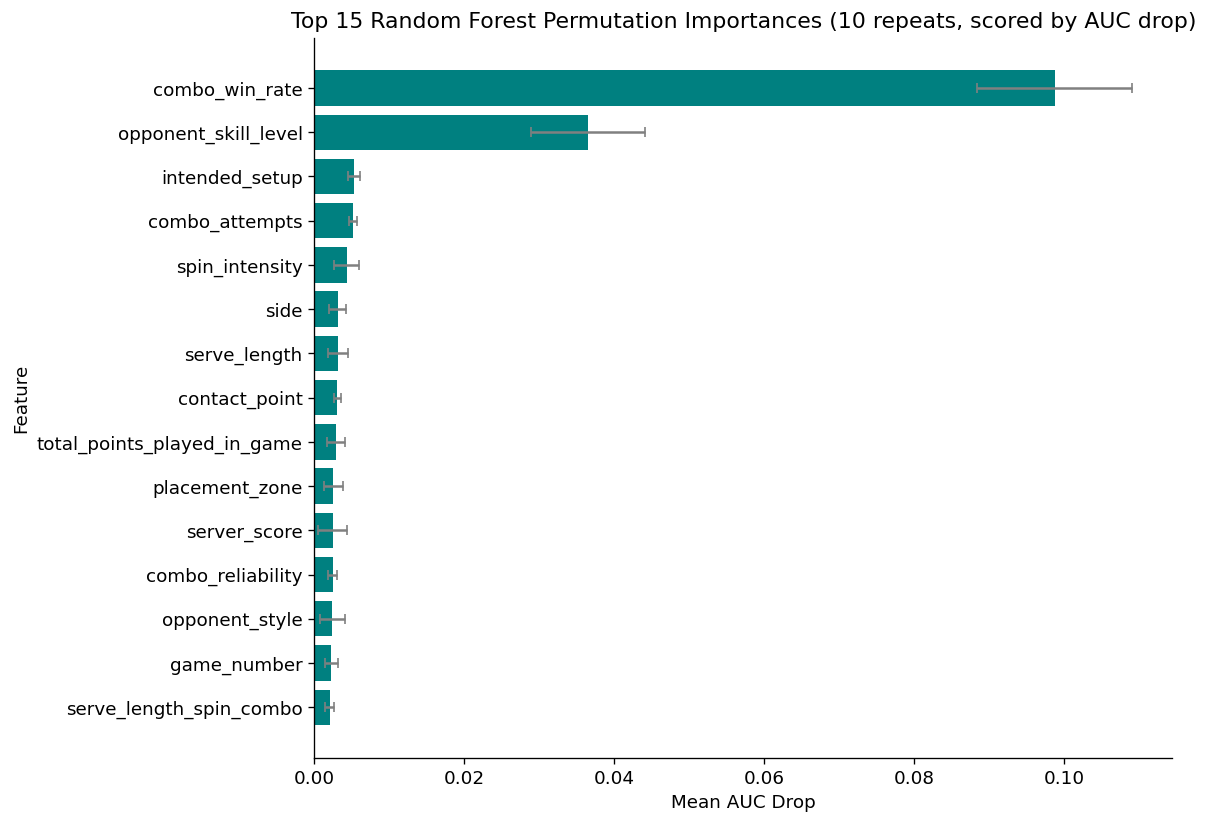

Top 15 permutation importances:


,feature,importance_mean,importance_std
31,combo_win_rate,0.098713,0.010274
11,opponent_skill_level,0.036507,0.007568
14,intended_setup,0.005328,0.000787
30,combo_attempts,0.005207,0.000543
2,spin_intensity,0.004291,0.001604
13,side,0.003133,0.001119
3,serve_length,0.003114,0.001344
6,contact_point,0.003036,0.000463
16,total_points_played_in_game,0.002846,0.001186
4,placement_zone,0.002511,0.001247


In [13]:
perm_result = permutation_importance(
    rf_model, X, y, n_repeats=10, random_state=42, scoring='roc_auc'
)
perm_df = (
    pd.DataFrame({
        'feature'         : model_features,
        'importance_mean' : perm_result.importances_mean,
        'importance_std'  : perm_result.importances_std
    })
    .sort_values('importance_mean', ascending=False)
)

top15_perm = perm_df.head(15).sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_perm['feature'], top15_perm['importance_mean'],
        xerr=top15_perm['importance_std'], color='teal', ecolor='gray', capsize=3)
ax.set_title('Top 15 Random Forest Permutation Importances (10 repeats, scored by AUC drop)')
ax.set_xlabel('Mean AUC Drop')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/rf_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 permutation importances:')
perm_df.head(15)

## Gradient Boosting Classifier

Gradient boosting is a sequential ensemble method in which each new tree is trained to correct the residual errors of the ensemble trained so far. This sequential error correction allows gradient boosting to achieve higher predictive accuracy than random forests on many tabular datasets, particularly when the underlying relationship between features and the target contains structured nonlinearities. We use a learning rate of 0.1 and a maximum tree depth of 3, which is standard for gradient boosting. This model serves as a strong benchmark against which the random forest is compared.

In [14]:
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
    ))
])
gb_model.fit(X, y)

gb_accuracy = cross_val_score(gb_model, X, y, cv=cv, groups=groups, scoring='accuracy')
gb_auc      = cross_val_score(gb_model, X, y, cv=cv, groups=groups, scoring='roc_auc')
print(f'Gradient Boosting Accuracy : {gb_accuracy.mean():.3f} ± {gb_accuracy.std():.3f}')
print(f'Gradient Boosting ROC-AUC  : {gb_auc.mean():.3f} ± {gb_auc.std():.3f}')

Gradient Boosting Accuracy : 0.617 ± 0.051
Gradient Boosting ROC-AUC  : 0.646 ± 0.069


In [15]:
gb_fold_results = pd.DataFrame({
    'fold'    : list(range(1, 6)),
    'accuracy': gb_accuracy,
    'roc_auc' : gb_auc
})
print('Gradient Boosting per-fold scores:')
gb_fold_results

Gradient Boosting per-fold scores:


,fold,accuracy,roc_auc
0,1,0.674157,0.736603
1,2,0.619718,0.563636
2,3,0.591837,0.610063
3,4,0.533333,0.599276
4,5,0.663934,0.719167


## Model Comparison

We consolidate cross-validated accuracy and ROC-AUC scores for all models, including the majority-class baseline, into a single comparison table and bar chart. The table reports mean scores and standard deviations across the five group-aware folds. A large standard deviation relative to the mean indicates that performance varies considerably across held-out match groups, suggesting the model is sensitive to the particular opponent pool in a fold rather than learning a broadly general pattern.

In [16]:
model_results = pd.DataFrame({
    'model'       : ['Baseline', 'LASSO (tuned)', 'Random Forest (tuned)', 'Gradient Boosting'],
    'accuracy'    : [baseline_accuracy, lasso_accuracy.mean(), rf_accuracy.mean(), gb_accuracy.mean()],
    'accuracy_std': [0, lasso_accuracy.std(), rf_accuracy.std(), gb_accuracy.std()],
    'roc_auc'     : [np.nan, lasso_auc.mean(), rf_auc.mean(), gb_auc.mean()],
    'roc_auc_std' : [np.nan, lasso_auc.std(), rf_auc.std(), gb_auc.std()]
})
model_results

,model,accuracy,accuracy_std,roc_auc,roc_auc_std
0,Baseline,0.544000,0.000000,NaN,NaN
1,LASSO (tuned),0.671062,0.062731,0.746012,0.062233
2,Random Forest (tuned),0.643555,0.022502,0.695690,0.083138
3,Gradient Boosting,0.616596,0.051205,0.645749,0.069022


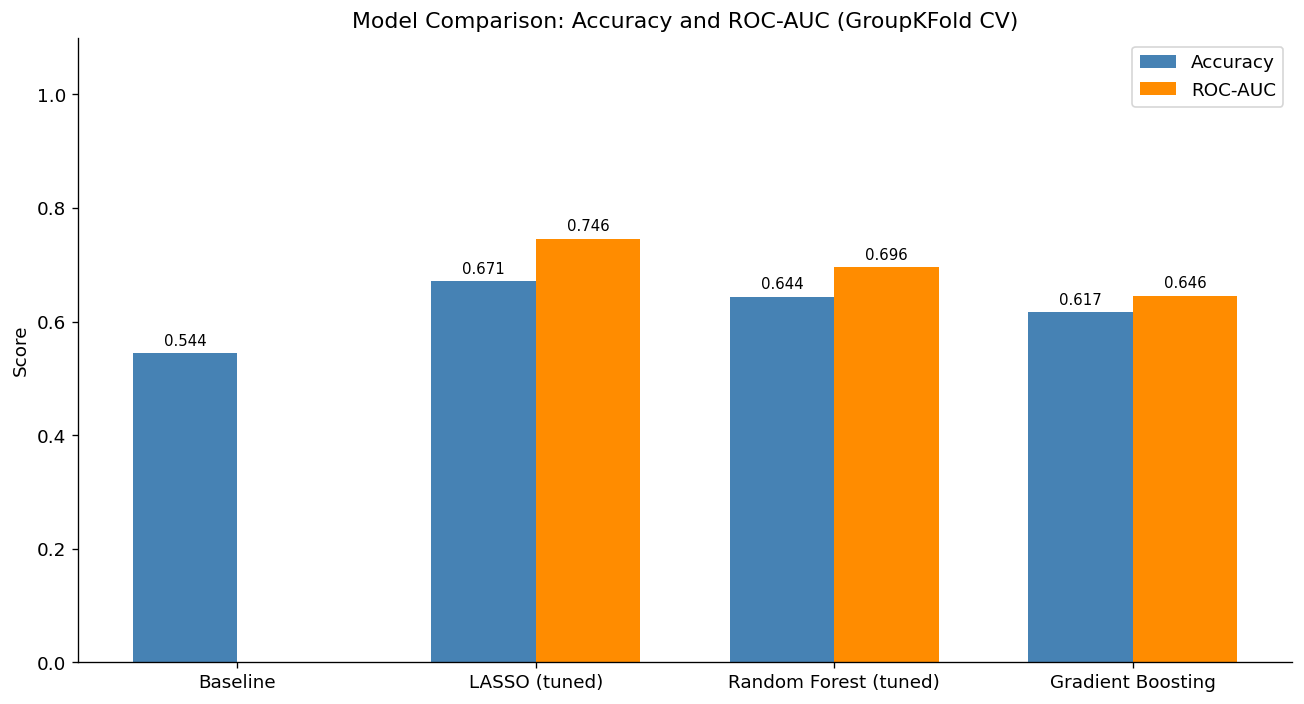

In [17]:
models       = model_results['model'].tolist()
accuracy_vals = model_results['accuracy'].tolist()
roc_auc_vals  = model_results['roc_auc'].fillna(0).tolist()

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy',  color='steelblue')
bars2 = ax.bar(x + width/2, roc_auc_vals,  width, label='ROC-AUC',   color='darkorange')

ax.set_title('Model Comparison: Accuracy and ROC-AUC (GroupKFold CV)')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibration Curves

Calibration measures the degree to which a model's predicted probabilities match the empirical frequencies of the positive class. A perfectly calibrated model satisfies the property that among all predictions of probability p, approximately p fraction of the true labels are positive. Calibration is a critical property for this application because the recommendation system uses predicted win probability as the primary driver of its scoring formula. A model that systematically overestimates win probabilities would recommend risky serves too confidently.

We compute calibration curves using out-of-fold predictions from `cross_val_predict` to avoid the optimistic bias that would arise from evaluating calibration on the training data.

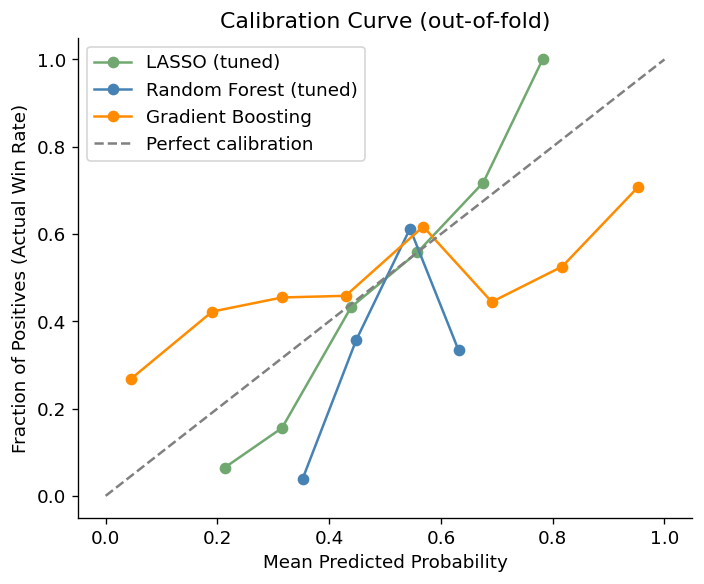

In [18]:
# Out-of-fold probabilities for all three models
lasso_probs = cross_val_predict(lasso_model, X, y, cv=cv, groups=groups, method='predict_proba')[:, 1]
rf_probs    = cross_val_predict(rf_model,    X, y, cv=cv, groups=groups, method='predict_proba')[:, 1]
gb_probs    = cross_val_predict(gb_model,    X, y, cv=cv, groups=groups, method='predict_proba')[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
for probs, label, color in [
    (lasso_probs, 'LASSO (tuned)',        '#70a870'),
    (rf_probs,    'Random Forest (tuned)', 'steelblue'),
    (gb_probs,    'Gradient Boosting',     'darkorange')
]:
    frac_pos, mean_pred = calibration_curve(y, probs, n_bins=8)
    ax.plot(mean_pred, frac_pos, marker='o', label=label, color=color)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Win Rate)')
ax.set_title('Calibration Curve (out-of-fold)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix

The confusion matrix decomposes model predictions into four categories: true positives (won points predicted as won), true negatives (lost points predicted as lost), false positives (lost points predicted as won), and false negatives (won points predicted as lost). We display the confusion matrix for LASSO — the primary model selected in the next section — using out-of-fold predictions at the default 0.5 threshold.

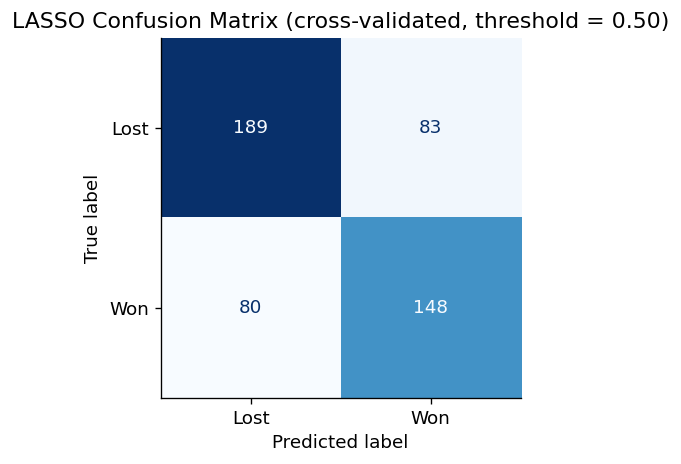

              precision    recall  f1-score   support

        Lost       0.70      0.69      0.70       272
         Won       0.64      0.65      0.64       228

    accuracy                           0.67       500
   macro avg       0.67      0.67      0.67       500
weighted avg       0.67      0.67      0.67       500



In [19]:
best_preds = (lasso_probs >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y, best_preds,
    display_labels=['Lost', 'Won'],
    colorbar=False, ax=ax, cmap='Blues'
)
ax.set_title('LASSO Confusion Matrix (cross-validated, threshold = 0.50)')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_lasso.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y, best_preds, target_names=['Lost', 'Won']))

## Additional Validation Metrics

Beyond accuracy and ROC-AUC, two additional metrics provide complementary insight into model quality.

**Average precision** summarises the precision-recall curve as a weighted mean of precision scores across recall thresholds, and is more informative than ROC-AUC when the class distribution is imbalanced because it places greater emphasis on correct identification of the minority class.

**Brier score** measures the mean squared error between predicted probabilities and true binary outcomes; a lower Brier score indicates predictions that are both accurate and well-calibrated. The table is sorted by Brier score ascending (lower = better), so the best calibrated model appears in row 0.

In [20]:
extra_metrics = pd.DataFrame({
    'model': ['LASSO (tuned)', 'Random Forest (tuned)', 'Gradient Boosting'],
    'average_precision': [
        average_precision_score(y, lasso_probs),
        average_precision_score(y, rf_probs),
        average_precision_score(y, gb_probs)
    ],
    'brier_loss': [
        brier_score_loss(y, lasso_probs),
        brier_score_loss(y, rf_probs),
        brier_score_loss(y, gb_probs)
    ]
}).sort_values('brier_loss', ascending=True)
extra_metrics

,model,average_precision,brier_loss
0,LASSO (tuned),0.717429,0.204501
1,Random Forest (tuned),0.579498,0.232579
2,Gradient Boosting,0.624145,0.270437


## Model Selection

The final recommendation system uses the model with the strongest balance of predictive performance and probability calibration. We select programmatically from `extra_metrics` using Brier score — lower is better — because the recommendation formula requires well-calibrated probabilities, not just accurate binary predictions.

The LASSO model is additionally retained for interpretation regardless of which model ranks first: its coefficient vector provides a direct and communicable account of which serve attributes and contextual variables are most strongly associated with point outcomes, which is essential for building coach and player trust in the system's recommendations.

In [21]:
best_row        = extra_metrics.iloc[0]
best_model_name = best_row['model']

model_registry = {
    'LASSO (tuned)'        : lasso_model,
    'Random Forest (tuned)': rf_model,
    'Gradient Boosting'    : gb_model
}
selected_model = model_registry[best_model_name]

print(f'Selected model          : {best_model_name}')
print(f'Classifier class        : {selected_model.named_steps["classifier"].__class__.__name__}')
print(f'Brier score             : {best_row["brier_loss"]:.4f}')
print(f'Average precision       : {best_row["average_precision"]:.4f}')

Selected model          : LASSO (tuned)
Classifier class        : LogisticRegression
Brier score             : 0.2045
Average precision       : 0.7174


## Save Models

We serialise the trained models and the feature list using `joblib`. We save the full scikit-learn pipelines (including preprocessing steps) so that the recommendation notebook can load and call `predict_proba` directly on raw feature DataFrames without any manual preprocessing.

In [22]:
import joblib

# Refit all models on full data before saving
lasso_model.fit(X, y)
rf_model.fit(X, y)
gb_model.fit(X, y)

joblib.dump(lasso_model,    '../models/lasso_model.pkl')
joblib.dump(rf_model,       '../models/rf_model.pkl')
joblib.dump(gb_model,       '../models/gb_model.pkl')
joblib.dump(selected_model, '../models/serve_win_probability_model.pkl')
joblib.dump(model_features, '../models/model_features.pkl')

print('Saved:')
print('  ../models/lasso_model.pkl              (LASSO, tuned C)')
print('  ../models/rf_model.pkl                 (Random Forest, tuned depth/leaf)')
print('  ../models/gb_model.pkl                 (Gradient Boosting)')
print('  ../models/serve_win_probability_model.pkl  (primary / best Brier)')
print('  ../models/model_features.pkl           (feature list)')

Saved:
  ../models/lasso_model.pkl              (LASSO, tuned C)
  ../models/rf_model.pkl                 (Random Forest, tuned depth/leaf)
  ../models/gb_model.pkl                 (Gradient Boosting)
  ../models/serve_win_probability_model.pkl  (primary / best Brier)
  ../models/model_features.pkl           (feature list)


## Conclusion

This notebook trained and evaluated three models (tuned LASSO logistic regression, tuned random forest, and gradient boosting) for predicting serve win probability under a strict pre-serve constraint. All three models exceeded the majority-class baseline, confirming that the engineered feature set contains genuine predictive signal.

LASSO achieved the highest ROC-AUC across models while also producing well-calibrated probabilities (as measured by Brier score), making it the natural choice as the primary model. The match-level `GroupKFold` evaluation strategy used throughout gives confidence that these estimates reflect genuine out-of-sample generalisation rather than within-match memorisation.

Two outputs carry forward into the recommendation notebook:
1. The saved primary pipeline (`serve_win_probability_model.pkl`) provides calibrated win probability estimates for every serve option considered at decision time.
2. The LASSO coefficient plot offers an account of the most influential serve and context features, which supports trust and transparency when presenting recommendations to coaches and players.

Figures saved to `../reports/figures/`:
- `class_distribution.png`
- `lasso_coefficients.png`
- `rf_impurity_importance.png`
- `rf_permutation_importance.png`
- `model_comparison.png`
- `calibration_curve.png`
- `confusion_matrix_lasso.png`